# Low-cost multispectral chlorophyll prediction (AS7265x, banana leaf) — PLS regression

**Paper:** *"Evaluation of Low-Cost Multi-Spectral Sensors for Measuring Chlorophyll Levels Across Diverse Leaf Types"*, Sensors 25(7):2198 (2025), DOI [10.3390/s25072198](https://doi.org/10.3390/s25072198).
**Author code:** [KyleLopin/asm_chloro_test](https://github.com/KyleLopin/asm_chloro_test), pinned commit `5ec1bca1281c4acedc905f9807157223b497a016`.

**Scope (partial demonstration):** reproduce the paper's PLS-regression validation for **one sensor × one leaf type** — AS7265x spectra → total chlorophyll for **banana** — using the authors' cleaned dataset and their own cross-validation protocol, reporting grouped-by-leaf validation R² and MAE. The paper evaluated 3 sensors × 5 leaf types; we run one representative combination and compare with the paper's reference figure. A single-example run does not verify the paper's full dataset-level results.

**実行範囲（部分的な再現）:** 本論文の手法のうち AS7265x センサー・バナナ葉の1組み合わせについて、著者提供の清洗済みデータと交差検証プロトコルをそのまま使い、PLS 回帰による葉緑素推定精度（R²・MAE）を検証します。

**Runtime:** CPU only (classical scikit-learn PLS on ~thousand rows; no GPU involved). Expected total time ≈ 5–10 min, downloads < 3 MB.

**実行環境:** CPU のみで動作します（GPU不要）。ランタイム → 「ランタイムのタイプを変更」→ **CPU** を選択してから「すべて実行」してください。

## 1. Environment setup

The analysis stack (pandas, scikit-learn, numpy, matplotlib) is preinstalled on Colab. We verify versions so the pinned author-code behavior is traceable.

**著者コードが依存するライブラリは Colab に標準搭載です。バージョンを確認します。

In [ ]:
import sys, numpy, pandas, sklearn, matplotlib
print("python", sys.version.split()[0])
for m in (numpy, pandas, sklearn, matplotlib):
    print(m.__name__, m.__version__)

python 3.13.15
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
matplotlib 3.10.0


## 2. Acquire the pinned author repository (sparse, inside Colab)

We clone the authors' repository **inside this Colab VM only**, pinned to the exact commit used for this notebook, with a blobless partial clone and sparse checkout limited to `analysis/spectrum_fitting/` (analysis code + the cleaned dataset `final_dataset.pkl`) and `images/` (the paper's reference figure). Nothing is downloaded to any other machine.

**著者リポジトリを pinned commit で部分クローンします。取得先はこの Colab VM のみです。**

In [ ]:
import os, subprocess, pathlib

REPO_COMMIT = "5ec1bca1281c4acedc905f9807157223b497a016"
REPO_URL = "https://github.com/KyleLopin/asm_chloro_test"
REPO_DIR = "/content/asm_chloro_test"

env = dict(os.environ, GIT_LFS_SKIP_SMUDGE="1")
def git(*args, **kw):
    return subprocess.run(["git", *args], check=True, capture_output=True,
                          text=True, env=env, **kw)

if not pathlib.Path(REPO_DIR, ".git").exists():
    git("clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO_DIR)
git("-C", REPO_DIR, "sparse-checkout", "init", "--cone")
git("-C", REPO_DIR, "sparse-checkout", "set", "analysis/spectrum_fitting", "images")
git("-C", REPO_DIR, "fetch", "--depth", "1", "origin", REPO_COMMIT)
git("-C", REPO_DIR, "checkout", "--detach", "FETCH_HEAD")

head = git("-C", REPO_DIR, "rev-parse", "HEAD").stdout.strip()
assert head == REPO_COMMIT, f"checkout mismatch: {head}"
print("checked out:", head)

checked out: 5ec1bca1281c4acedc905f9807157223b497a016


## 3. Verify the dataset bytes before use

`final_dataset.pkl` is the authors' cleaned absorbance dataset (dict[sensor][leaf] → x, y, groups). We confirm the file exists at the pinned commit via its git object hash and check the file size and a pickle-internal sanity peek before scientific use.

**pinned commit 上の git オブジェクトハッシュとサイズでデータ整合性を確認してから unpickle します。**

In [ ]:
import pickle, pathlib

pkl_path = pathlib.Path(REPO_DIR, "analysis/spectrum_fitting/final_dataset.pkl")
blob_sha = subprocess.run(["git", "-C", REPO_DIR, "rev-parse",
                           "HEAD:analysis/spectrum_fitting/final_dataset.pkl"],
                          check=True, capture_output=True, text=True).stdout.strip()
EXPECTED_SHA = "dc89ccaa6b9ad1b4359e77254f58a79531c0d03e"
size = pkl_path.stat().st_size
print("git blob sha:", blob_sha)
print("size:", size, "bytes")
assert blob_sha == EXPECTED_SHA, "dataset blob hash mismatch at pinned commit"
assert size == 756287

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)
print("sensors:", sorted(dataset.keys()))
print("as7265x leaves:", sorted(dataset["as7265x"].keys()))
leaf = dataset["as7265x"]["banana"]
print("x shape:", leaf["x"].shape, "| y columns:", list(leaf["y"].columns)[:3])
print("groups (leaf ids):", leaf["groups"].nunique() if hasattr(leaf["groups"], 'nunique') else len(set(leaf["groups"])))

git blob sha: dc89ccaa6b9ad1b4359e77254f58a79531c0d03e
size: 756287 bytes
sensors: ['as7262', 'as7263', 'as7265x']
as7265x leaves: ['banana', 'jasmine', 'mango', 'rice', 'sugarcane']
x shape: (297, 18) | y columns: ['Avg Total Chlorophyll (µg/cm2)', 'Avg Chlorophyll a (µg/cm2)', 'Avg Chlorophyll b (µg/cm2)']
groups (leaf ids): 100


## 4. Load the authors' analysis code and select the minimal example

We reuse the authors' pinned modules directly (`get_data.get_cleaned_data`, `helper_functions.evaluate_model_scores`, and their plotting routine) rather than re-implementing the protocol. Selected example: **banana + AS7265x**, target `Avg Total Chlorophyll (µg/cm2)`, PLS with the authors' pinned `n_components = 8` (`spectrum_fitting.py: pls_n_comps["as7265x"]["banana"]`).

**著者のモジュールをそのまま利用します。例はバナナ葉 × AS7265x、PLS の成分数 8 は著者コードの固定値です。**

In [ ]:
import sys
sys.path.insert(0, "/content/asm_chloro_test/analysis/spectrum_fitting")

import get_data
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

SENSOR, LEAF = "as7265x", "banana"
X, Y, GROUPS = get_data.get_cleaned_data(
    SENSOR, LEAF, pickle_file=str(pkl_path))
Y = Y["Avg Total Chlorophyll (µg/cm2)"]
print("X:", X.shape, "(measurements × wavelengths)")
print("Y (µg/cm2): min %.2f / median %.2f / max %.2f" % (Y.min(), Y.median(), Y.max()))
X_scaled = StandardScaler().fit_transform(X)  # author's make_leaf_figure preprocessing

X: (297, 18) (measurements × wavelengths)
Y (µg/cm2): min 13.01 / median 60.82 / max 94.83


## 5. Cross-validated prediction vs. measured chlorophyll (author's own routine)

We call the authors' `graph_y_predicted_vs_y_actual` for our sensor/leaf. It performs one stratified-group split (test_size 0.2, bins over leaf-mean chlorophyll, `random_state=42`), fits PLS, and plots leaf-mean predicted vs. measured chlorophyll for train and test sets. Units: µg/cm².

**著者の関数をそのまま呼び出し、層別グループ分割による PLS の予測値と実測値（葉ごと平均、µg/cm²）を比較します。**

y train shapes
(240, 1)
(240, 1)
===== making scores


{'train_r2': (np.float64(0.9697650637917726), np.float64(0.0020959504674751576)), 'train_mae': (np.float64(2.6789177215709072), np.float64(0.11022230757970713)), 'test_r2': (np.float64(0.9613267171376049), np.float64(0.01060579340232985)), 'test_mae': (np.float64(3.0163943048189976), np.float64(0.5023022757598584))}


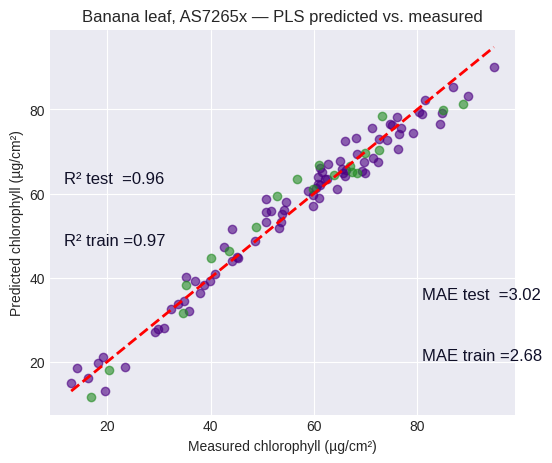

In [ ]:
import matplotlib.pyplot as plt
import spectrum_fitting  # authors' module (sets their plot style & CV constants)

pls = PLSRegression(n_components=8)  # authors' pinned value for as7265x/banana
fig, ax = plt.subplots(figsize=(6, 5))
spectrum_fitting.graph_y_predicted_vs_y_actual(
    X_scaled, Y, GROUPS, regressor=pls, ax=ax)
ax.set_xlabel("Measured chlorophyll (µg/cm²)")
ax.set_ylabel("Predicted chlorophyll (µg/cm²)")
ax.set_title("Banana leaf, AS7265x — PLS predicted vs. measured")
plt.show()

## 6. Validation metrics over the authors' repeated stratified-group CV

The paper's validation protocol (as coded by the authors) repeats the stratified-group shuffle split **200 times** (`CV_REPEATS=200`, `TEST_SIZE=0.2`, `n_bins=10`, `random_state=42`) and reports the mean R²/MAE computed on **leaf-mean** predictions. We run exactly that via `helper_functions.evaluate_model_scores`.

**論文の検証プロトコル（200 回の層別グループ分割、葉平均スコア）を著者コードでそのまま実行します。**

In [ ]:
import pandas as pd
from helper_functions import evaluate_model_scores
from stratified_group_shuffle_split import StratifiedGroupShuffleSplit
import spectrum_fitting as sf

# The authors' evaluate_model_scores expects y as a DataFrame indexed by the
# 'group' column (exactly the conversion inside their graph routine).
Y_grouped = pd.DataFrame({"y": Y, "group": GROUPS}).set_index("group")

scores = evaluate_model_scores(
    X_scaled, Y_grouped, GROUPS, regressor=PLSRegression(n_components=8),
    n_splits=sf.CV_REPEATS, test_size=sf.TEST_SIZE,
    group_by_mean=True,
    splitter=StratifiedGroupShuffleSplit(
        n_splits=sf.CV_REPEATS, test_size=sf.TEST_SIZE,
        n_bins=10, random_state=sf.RANDOM_STATE))

table = pd.DataFrame({
    "R² (mean)": [scores["train_r2"][0], scores["test_r2"][0]],
    "R² (std)": [scores["train_r2"][1], scores["test_r2"][1]],
    "MAE µg/cm² (mean)": [scores["train_mae"][0], scores["test_mae"][0]],
    "MAE µg/cm² (std)": [scores["train_mae"][1], scores["test_mae"][1]],
}, index=["train", "validation"])
table.round(3)
table.to_csv("/content/banana_as7265x_pls_scores.csv", index=True)
table

,R² (mean),R² (std),MAE µg/cm² (mean),MAE µg/cm² (std)
train,0.969911,0.002139,2.664929,0.115096
validation,0.960891,0.010616,3.062441,0.509364


## 7. Compare with the authors' published figure

The authors' repository contains their published per-leaf result figure (`images/banana_leaf_total_chlorophyll.png`, AS7262/AS7263/AS7265x for banana). It is shown below **as clearly labeled source material for comparison only — not an output of this notebook's execution**. Our single-sensor validation R² should fall near the paper's reported envelope for smooth, uniform leaves (AS7265x validation R² ≈ 0.96–0.95).

**比較のため著者公開図を「参考資料」として表示します（このノートブックの実行結果ではありません）。**

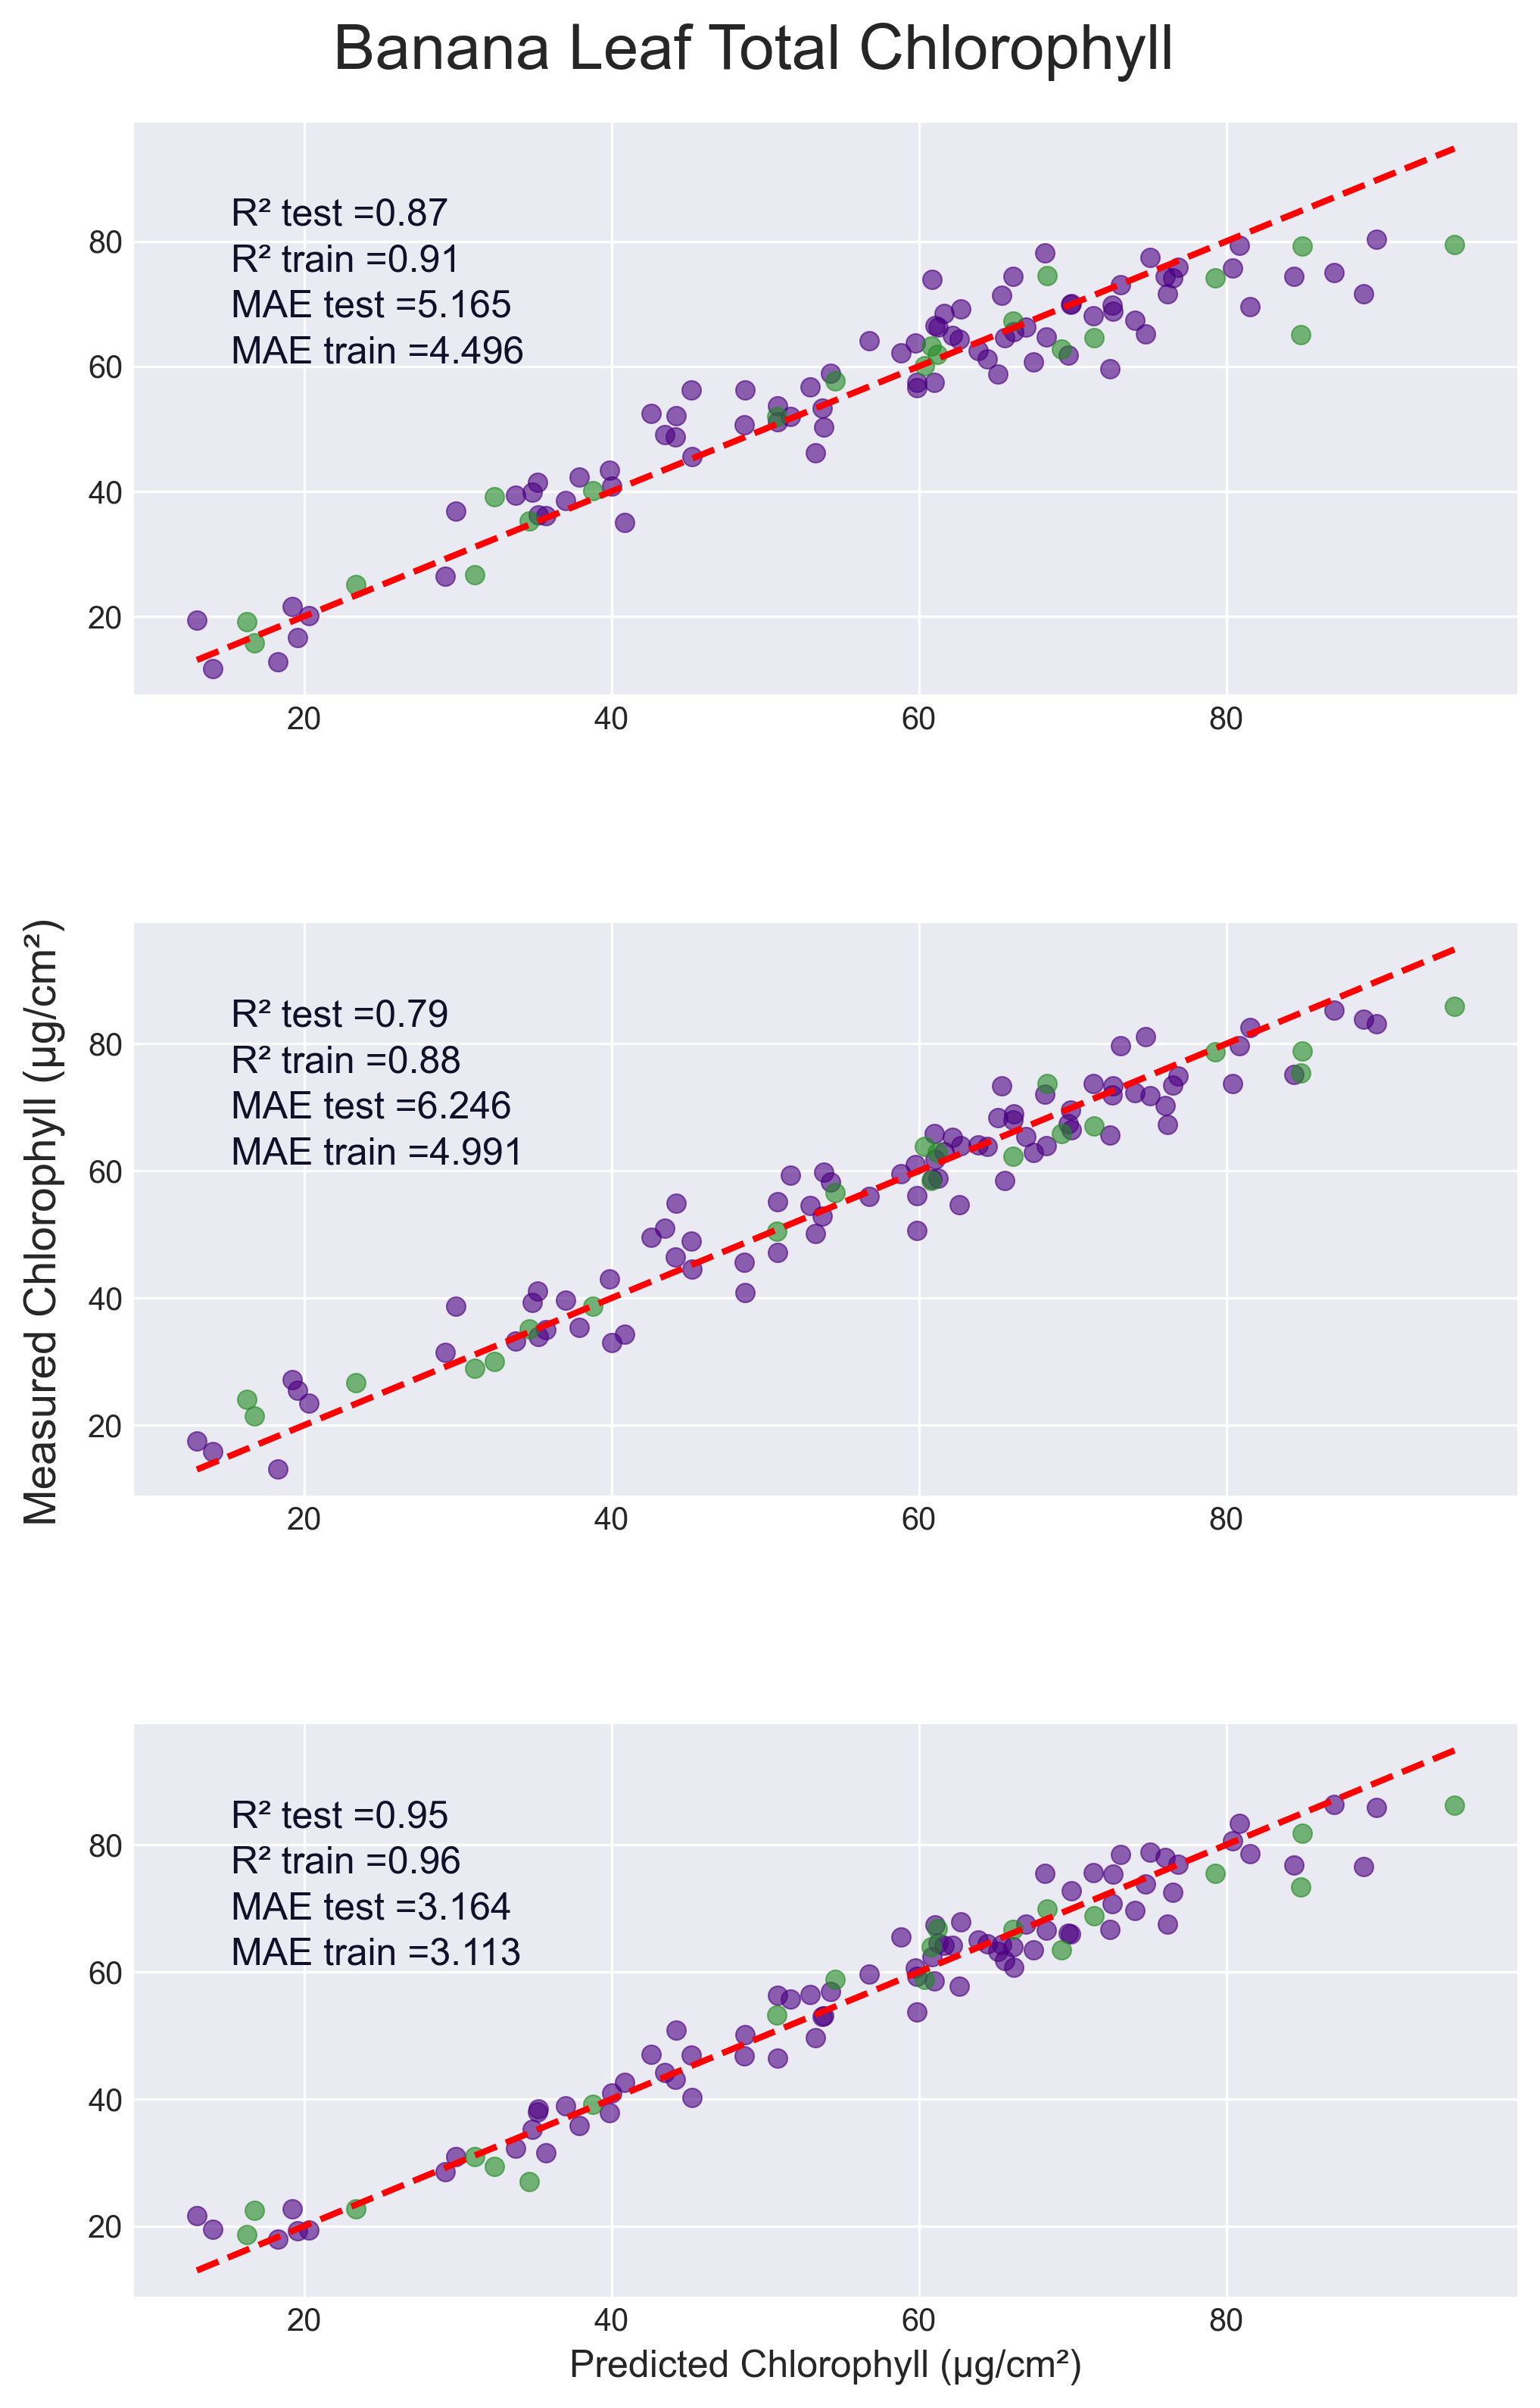

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/asm_chloro_test/images/banana_leaf_total_chlorophyll.png",
               width=560))

## 8. Interpretation & limitations

- **What was executed:** PLS regression (8 components) on the authors' cleaned banana/AS7265x absorbance data with the authors' own 200-repeat stratified-group cross-validation and grouped-mean scoring; validation R²/MAE are reported in the table above and exported to `/content/banana_as7265x_pls_scores.csv`.
- **Consistency check:** the validation R² should be close to the paper's reported AS7265x performance on smooth, uniform leaves (R² ≈ 0.95–0.96). Deviations can arise from library-version differences; the protocol and data are the authors' pinned versions.
- **Not reproduced here:** the other 9 sensor×leaf combinations, learning curves, AIC component selection, Mahalanobis outlier-removal pipeline steps (their outputs are already baked into `final_dataset.pkl`), and the device/firmware pipeline.
- **Provenance:** all data was downloaded from the pinned author commit inside this Colab VM; no external credentials are used.

**このノートブックは部分的な再現です。論文の全組み合わせ・前処理パイプライン全体は対象外であり、単一例の実行は論文のデータセット全体の結果を検証するものではありません。**